# Example 6 — Practical Applications & Benchmarking

This notebook demonstrates practical analysis workflows built on NMC simulation
outputs.

---

## Sections

### Max penetration depth
Histogram of the deepest point reached by **top-escaped** photons (Laser and
Raman), with fitted curves:

- **Laser** — exponential fit (characterises backscattering depth scale)
- **Raman** — gamma distribution fit (physically appropriate for the depth of
  the first inelastic event along a random walk)

### Raman birth depth
Histogram of the z-coordinate at which each Raman photon first appears
(first row with `type == 2` in the trajectory), for photons that escape via
the **bottom surface** (transmitted).  Shows from what median depth transmitted
Raman signal originates.

### Spatially Offset Raman Spectroscopy (SORS)
Two quantities plotted against radial offset $r$ on a dual y-axis:

- **Left axis** — Raman radiance RD($r$): radially averaged from the 2-D
  `rd_data` map
- **Right axis** — penetration depth $z_\text{max}(r)$: for top-escaped
  Raman photons binned by exit radial position $R = \sqrt{x^2 + y^2}$

Together these show the SORS depth-selectivity characteristic: larger radial
offset selects photons that have penetrated deeper.

---

## Output files used

| File pattern | Contents |
|---|---|
| `photons_data_mus-*_NA-*_zf-*.csv` | Full trajectories — used for all analyses |
| `rd_data_mus-*_NA-*_zf-*.csv` | 2-D radiance map — used for SORS RD profile |

---

## Requirements

At least **one** of the following simulations must have been run before
executing this notebook:

| µs (mm⁻¹) | ls (mm) | Expected file |
|-----------|---------|---------------|
| 10 | 0.1 | `photons_data_mus-10.00_NA-*_zf-*.csv` |
| 1 | 1.0 | `photons_data_mus-1.00_NA-*_zf-*.csv` |
| 0.1 | 10.0 | `photons_data_mus-0.10_NA-*_zf-*.csv` |

---

## Workflow

1. Set paths and µs values to analyse 
2. Discover available simulation outputs; warn about missing ones 
3. Load all available photon trajectory files 
4. Depth histogram - max penetration depth of top-escaped photons 
5. Raman birth depth - where in the medium Raman photons are generated 
6. SORS - radial Raman RD profile and max-depth vs radial offset 


> **Tip:** Run examples 1 or 2 first for each µs value you want to include,
> then return here.

In [17]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import gamma
from scipy.optimize import curve_fit

NOTEBOOK_DIR = Path("/Users/vladykilya/Documents/Xcode/raman2nmc/NMC-samples") #Path.cwd()
sys.path.insert(0, str(NOTEBOOK_DIR))
import nmc_utils as nmc

nmc.set_paper_style()
print("nmc_utils loaded")

nmc_utils loaded


In [45]:
# ── paths ─────────────────────────────────────────────────────────────────────
EXE_DIR  = (NOTEBOOK_DIR / "../NMC/Build/Products/Debug").resolve()

# Hokr reference data root — set to None to skip benchmarking entirely
# Each subdirectory data_01 / data_1 / data_10 must contain *_pump_b.dat etc.
HOKR_ROOT = None
# Override to None if you don't have the reference data:
# HOKR_ROOT = None

# ── scattering coefficients to analyse ───────────────────────────────────────
# Notebook will load whichever of these have matching output files in EXE_DIR.
MUS_VALUES = [10.0, 1.0, 0.1]          # mm⁻¹
NA         = 1.0
ZF         = 1.0

# ── depth histogram controls ──────────────────────────────────────────────────
DEPTH_BINS  = 40
DEPTH_STAT  = "density"     # "density" or "probability"
ADD_FITS    = True

# ── SORS controls ─────────────────────────────────────────────────────────────
SORS_MUS    = 1.0           # which µs to use for SORS plot
SORS_DR     = 0.05          # radial bin width (mm)

# ── figure output ─────────────────────────────────────────────────────────────
SAVE_FIGS = True
FIGS_DIR  = NOTEBOOK_DIR / "figs"
FIGS_DIR.mkdir(exist_ok=True)

print(f"EXE_DIR   : {EXE_DIR}")
print(f"HOKR_ROOT : {HOKR_ROOT}")

EXE_DIR   : /Users/vladykilya/Documents/Xcode/raman2nmc/NMC/Build/Products/Debug
HOKR_ROOT : None


In [20]:
# ── find which µs values have both photons + rd output files ──────────────────
available   = {}   # mus -> {"photons": Path, "rd": Path}
missing     = []

for mus in MUS_VALUES:
    pat_ph = f"photons_data_mus-{mus:.2f}_NA-{NA:.2f}_zf-{ZF:.2f}.csv"
    pat_rd = f"rd_data_mus-{mus:.2f}_NA-{NA:.2f}_zf-{ZF:.2f}.csv"
    found_ph = nmc.find_outputs(pat_ph, workdir=EXE_DIR)
    found_rd = nmc.find_outputs(pat_rd, workdir=EXE_DIR)
    if found_ph and found_rd:
        available[mus] = {"photons": found_ph[0], "rd": found_rd[0]}
        print(f"  ✓  µs = {mus:5.1f} mm-1  (ls = {1/mus:.2f} mm)")
    else:
        missing.append(mus)
        missing_files = []
        if not found_ph: missing_files.append(pat_ph)
        if not found_rd:  missing_files.append(pat_rd)
        print(f"  ✗  µs = {mus:5.1f} mm-1  — missing: {missing_files}")

if not available:
    raise RuntimeError(
        "No output files found for any µs value.\n"
        "Run the simulation (examples 1 or 2) for at least one µs value first."
    )

if missing:
   print(
        f"\nMissing outputs for µs = {missing} mm-1. Those values will be skipped in all plots.",

    )

print(f"\n{len(available)} dataset(s) available: µs = {list(available.keys())} mm-1")

  ✓  µs =  10.0 mm-1  (ls = 0.10 mm)
  ✓  µs =   1.0 mm-1  (ls = 1.00 mm)
  ✓  µs =   0.1 mm-1  (ls = 10.00 mm)

3 dataset(s) available: µs = [10.0, 1.0, 0.1] mm-1


In [24]:
# datasets[mus] = {"df_raw": ..., "df_summary": ..., "rd": ...}
datasets = {}

for mus, paths in available.items():
    width = 5.0    # mm — adjust if you ran with a different width
    Nx = Ny = 100  # adjust if needed

    print(f"\n--- loading µs = {mus} mm-1 ---")

    df_raw, df_summary = nmc.load_photons(
        paths["photons"],
        z_bottom=width,
    )
    rd = nmc.load_rd_data(paths["rd"], Nx=Nx, Ny=Ny)

    # attach readable labels
    df_raw["type_label"]     = df_raw["type"].map(nmc.TYPE_LABELS)
    df_summary["type_label"] = df_summary["prev_type"].map(nmc.TYPE_LABELS)

    # birth depth: first row per marker where type == 2
    birth_z = (
        df_raw[df_raw["type"] == 2]
        .groupby("marker")["z"]
        .first()
        .reset_index()
        .rename(columns={"z": "z_birth"})
    )
    df_summary = df_summary.merge(birth_z, on="marker", how="left")

    datasets[mus] = {
        "df_raw":     df_raw,
        "df_summary": df_summary,
        "rd":         rd,
        "width":      width,
        "Nx":         Nx,
        "Ny":         Ny,
    }

print("\nAll datasets loaded and processed.")


--- loading µs = 10.0 mm-1 ---
[load_photons] Total rows       : 12,097,245
[load_photons] Unique markers   : 100,000
[load_photons] Summarised       : 100,000  (after type filter: [1, 2, 3])

[load_photons] Exit state counts (post-filter):
absorbed    56841
top         43043
bottom        116

[load_photons] prev_type counts (post-filter):
1    82055
2    17945

--- loading µs = 1.0 mm-1 ---
[load_photons] Total rows       : 9,584,473
[load_photons] Unique markers   : 100,000
[load_photons] Summarised       : 100,000  (after type filter: [1, 2, 3])

[load_photons] Exit state counts (post-filter):
absorbed    84705
top          8696
bottom       6599

[load_photons] prev_type counts (post-filter):
1    82172
2    17828

--- loading µs = 0.1 mm-1 ---
[load_photons] Total rows       : 10,388,641
[load_photons] Unique markers   : 100,000
[load_photons] Summarised       : 100,000  (after type filter: [1, 2, 3])

[load_photons] Exit state counts (post-filter):
absorbed    55837
bottom     

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


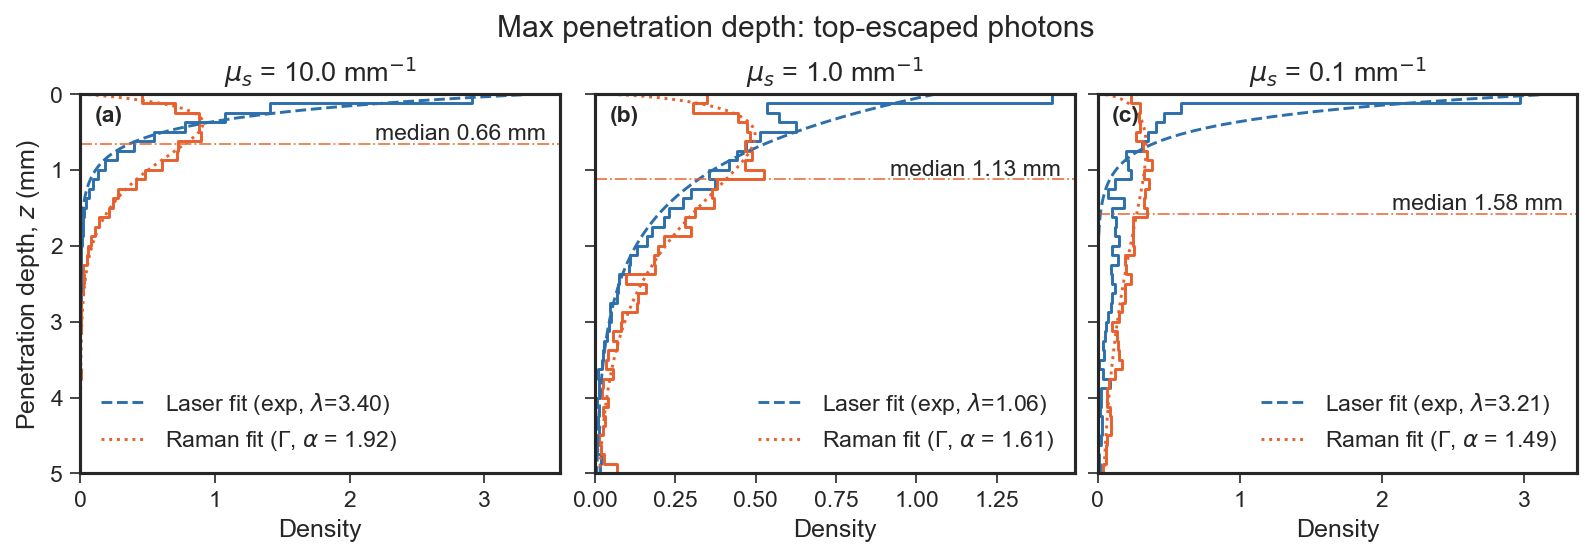

In [37]:
# helpers
import warnings

def _exp_pdf(z, lam):
                return lam * np.exp(-lam * z)

def _gamma_pdf(z, a, scale):
    return gamma.pdf(z, a=a, scale=scale)

# comtrols
_FIG_SIZES_DH = {1: (3.5, 3.6), 2: (7.0, 3.6)}
_PANEL_LABELS = ["(a)", "(b)", "(c)"]

n_panels = len(available)
figsize  = _FIG_SIZES_DH.get(n_panels, (3.5 * n_panels, 3.6))

fig, axes = plt.subplots(1, n_panels, figsize=figsize, sharey=True)
if n_panels == 1:
    axes = [axes]

palette = {
    nmc.TYPE_LABELS[1]: nmc.TYPE_COLORS[1],
    nmc.TYPE_LABELS[2]: nmc.TYPE_COLORS[2],
}

for idx, (ax, mus) in enumerate(zip(axes, available)):
    ds    = datasets[mus]
    summ  = ds["df_summary"]
    width = ds["width"]

    sel = summ[
        (summ["exit_state"]  == "top") &
        (summ["prev_type"].isin([1, 2])) &
        (summ["term_mode"]   == "term")
    ].copy()
    sel["Type"] = sel["prev_type"].map(nmc.TYPE_LABELS)

    bin_edges   = np.linspace(0.0, width, DEPTH_BINS + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    sns.histplot(
        data=sel,
        y="max_z",
        hue="Type",
        bins=bin_edges,
        stat=DEPTH_STAT,
        common_norm=False,
        element="step",
        fill=False,
        linewidth=1.4,
        palette=palette,
        ax=ax,
        legend=(ax == axes[0]),
    )

    ax.set_ylim(0.0, width)
    ax.invert_yaxis()   # z = 0 at top
    ax.set_ylabel("Penetration depth, $z$ (mm)" if ax == axes[0] else "")
    ax.set_xlabel(DEPTH_STAT.capitalize())
    ax.set_title(fr"$\mu_s$ = {mus} mm$^{{-1}}$")
    ax.grid(False)

    ax.text(
        0.03, 0.97, _PANEL_LABELS[idx],
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=plt.rcParams["legend.fontsize"],
        fontweight="bold",
    )

    # fitting curves 
    if ADD_FITS:
        z_grid = np.linspace(0.0, width, 400)

        # Laser — exponential fit on binned data
        laser_z = sel.loc[sel["Type"] == nmc.TYPE_LABELS[1], "max_z"].to_numpy()
        if len(laser_z) > 10:
            counts_l, _ = np.histogram(laser_z, bins=bin_edges, density=True)
            mask_l = counts_l > 0

            try:
                popt_l, _ = curve_fit(
                    _exp_pdf,
                    bin_centers[mask_l],
                    counts_l[mask_l],
                    p0=[1.0 / (laser_z.mean() + 1e-9)],
                    bounds=(0, np.inf),
                    maxfev=4000,
                )
                lam_fit = float(popt_l[0])
                ax.plot(
                    _exp_pdf(z_grid, lam_fit), z_grid,
                    linestyle="--", linewidth=1.4,
                    color=nmc.TYPE_COLORS[1],
                    label=fr"Laser fit (exp, $\lambda$={lam_fit:.2f})",
                )
            except RuntimeError:
                warnings.warn(fr"Laser exponential fit failed for $\mu_s$ = {mus}.")

        # Raman — gamma distribution fit
        raman_z = sel.loc[sel["Type"] == nmc.TYPE_LABELS[2], "max_z"].to_numpy()
        if len(raman_z) > 10:
            counts_r, _ = np.histogram(raman_z, bins=bin_edges, density=True)
            mask_r = counts_r > 0

            try:
                # moment-matching starting guess
                mu_r  = raman_z.mean()
                var_r = raman_z.var() + 1e-9
                p0_r  = [mu_r**2 / var_r, var_r / mu_r]
                popt_r, _ = curve_fit(
                    _gamma_pdf,
                    bin_centers[mask_r],
                    counts_r[mask_r],
                    p0=p0_r,
                    bounds=([0, 0], [np.inf, np.inf]),
                    maxfev=4000,
                )
                a_fit, sc_fit = float(popt_r[0]), float(popt_r[1])
                ax.plot(
                    _gamma_pdf(z_grid, a_fit, sc_fit), z_grid,
                    linestyle=":", linewidth=1.4,
                    color=nmc.TYPE_COLORS[2],
                    label=fr"Raman fit (Γ, $\alpha$ = {a_fit:.2f})",
                )
            except RuntimeError:
                warnings.warn(fr"Raman gamma fit failed for $\mu_s$ = {mus}.")

            # median line
            med = float(np.median(raman_z))
            ax.axhline(med, linestyle="-.", linewidth=0.9,
                       color=nmc.TYPE_COLORS[2], alpha=0.8)
            ax.text(
                0.97, med, f"median {med:.2f} mm",
                ha="right", va="bottom",
                transform=ax.get_yaxis_transform(),
                fontsize=plt.rcParams["legend.fontsize"],
            )

    handles, labels = ax.get_legend_handles_labels()
    if handles:
        leg = ax.legend(frameon=False,
                        fontsize=plt.rcParams["legend.fontsize"])

fig.suptitle("Max penetration depth: top-escaped photons")

if SAVE_FIGS:
    fig.savefig(FIGS_DIR / "ex6_depth_histogram.pdf", bbox_inches="tight")
plt.show()

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


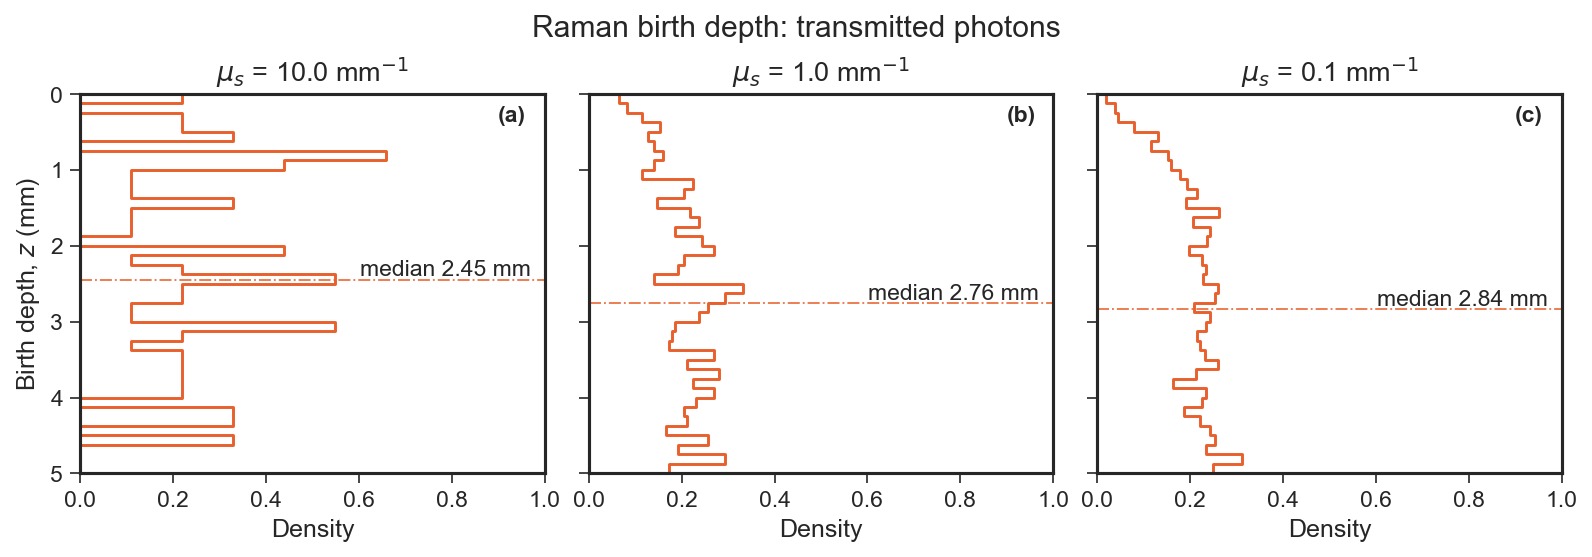

In [43]:
# controls
_FIG_SIZES_BD = {1: (3.5, 3.6), 2: (7.0, 3.6)}
_PANEL_LABELS = ["(a)", "(b)", "(c)"]

n_panels = len(available)
figsize  = _FIG_SIZES_BD.get(n_panels, (3.5 * n_panels, 3.6))
fig, axes = plt.subplots(1, n_panels, figsize=figsize, sharey=True)
if n_panels == 1:
    axes = [axes]

for idx, (ax, mus) in enumerate(zip(axes, available)):
    ds    = datasets[mus]
    summ  = ds["df_summary"]
    width = ds["width"]

    # bottom-escaped Raman photons only — one row per marker
    sel = summ[
        (summ["exit_state"] == "bottom") &
        (summ["prev_type"]  == 2) &
        (summ["term_mode"]  == "term") &
        (summ["z_birth"].notna())
    ].copy()

    if sel.empty:
        ax.set_title(f"$\\mu_s$ = {mus} mm$^{{-1}}$")
        continue

    bin_edges = np.linspace(0.0, width, DEPTH_BINS + 1)

    sns.histplot(
        data=sel,
        y="z_birth",
        bins=bin_edges,
        stat=DEPTH_STAT,
        element="step",
        fill=False,
        linewidth=1.4,
        color=nmc.TYPE_COLORS[2],
        ax=ax,
        label="Raman",
    )
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, width)
    ax.invert_yaxis()
    ax.set_ylabel("Birth depth, $z$ (mm)" if ax == axes[0] else "")
    ax.set_xlabel(DEPTH_STAT.capitalize())
    ax.set_title(f"$\\mu_s$ = {mus} mm$^{{-1}}$")
    ax.grid(False)

     # panel label — top-left, matching example5 style
    ax.text(
        0.9, 0.97, _PANEL_LABELS[idx],
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=plt.rcParams["legend.fontsize"],
        fontweight="bold",
    )

    # median annotation
    med = float(sel["z_birth"].median())
    ax.axhline(med, linestyle="-.", linewidth=0.9,
               color=nmc.TYPE_COLORS[2], alpha=0.85)
    ax.text(
        0.97, med, f"median {med:.2f} mm",
        ha="right", va="bottom",
        transform=ax.get_yaxis_transform(),
        fontsize=plt.rcParams["legend.fontsize"],
    )

fig.suptitle("Raman birth depth: transmitted photons")

if SAVE_FIGS:
    fig.savefig(FIGS_DIR / "ex6_raman_birth_depth.pdf", bbox_inches="tight")
plt.show()

/var/folders/l8/jct10p7j6j32y_vynt7lbf9r0000gq/T/ipykernel_44065/34004618.py:101: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


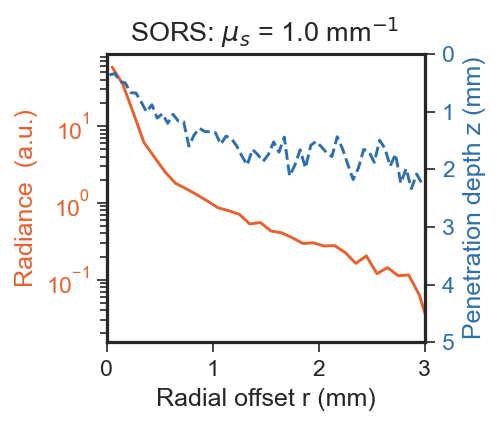

In [60]:
if SORS_MUS not in available:
    raise RuntimeError(
        f"SORS_MUS = {SORS_MUS} mm$^{{-1}}$ is not in the available datasets.\n"
        f"Available: {list(available.keys())} mm$^{{-1}}$"
    )

ds    = datasets[SORS_MUS]
summ  = ds["df_summary"]
rd    = ds["rd"]
width = ds["width"]
Nx    = ds["Nx"]
Ny    = ds["Ny"]
df_raw = ds["df_raw"]

# 1. Raman RD radial profile from rd_data 2-D array 
x_arr, y_arr = nmc.build_xy_coords(Nx, Ny, width)
dx = x_arr[1] - x_arr[0]

def _radial_profile(arr: np.ndarray) -> tuple:
    ix  = np.arange(Nx)
    iy  = np.arange(Ny)
    IY, IX = np.meshgrid(iy, ix)
    R_pix = np.sqrt((IX - Nx/2)**2 + (IY - Ny/2)**2)
    r_max = int(np.floor(min(Nx, Ny) / 2))
    profile = np.zeros(r_max)
    for ri in range(r_max):
        mask = (R_pix >= ri) & (R_pix < ri + 1)
        profile[ri] = arr[mask].mean() if mask.any() else 0.0
    r_mm = (np.arange(r_max) + 0.5) * dx
    return r_mm,profile #np.log1p(profile)

r_rd, raman_rd_profile = _radial_profile(rd["raman"])

# 2. max_z(r) — top-escaped Raman photons, binned by exit R 
# get exit (x, y) from termination rows in df_raw
term_rows = (
    df_raw[df_raw["type"] == 0]
    .groupby("marker")[["x","y"]]
    .last()
    .reset_index()
)

raman_top = summ[
    (summ["prev_type"]  == 2) &
    (summ["exit_state"] == "top") &
    (summ["term_mode"]  == "term")
][["marker","max_z"]].merge(term_rows, on="marker")

raman_top["R_exit"] = np.sqrt(raman_top["x"]**2 + raman_top["y"]**2)

# radial bins
r_max_sors = 3               # mm
r_bins     = np.arange(0.0, r_max_sors + SORS_DR, SORS_DR)
r_centers  = 0.5 * (r_bins[:-1] + r_bins[1:])

max_z_r = np.full(len(r_centers), np.nan)
for i, (r_lo, r_hi) in enumerate(zip(r_bins[:-1], r_bins[1:])):
    mask = (raman_top["R_exit"] >= r_lo) & (raman_top["R_exit"] < r_hi)
    vals = raman_top.loc[mask, "max_z"].values
    if len(vals) > 0:
        max_z_r[i] = float(np.mean(vals))

# 3. dual-axis plot 
fig, ax1 = plt.subplots(figsize=(3.5, 3.0))
ax2 = ax1.twinx()

# left axis — Raman RD profile
l1, = ax1.plot(
    r_rd, raman_rd_profile,
    color=nmc.TYPE_COLORS[2], linewidth=1.4,
    label="Raman RD",
)
ax1.set_xlabel("Radial offset r (mm)")
ax1.set_ylabel("Radiance  (a.u.)", color=nmc.TYPE_COLORS[2])
ax1.tick_params(axis="y", labelcolor=nmc.TYPE_COLORS[2])
ax1.set_xlim(0, r_max_sors)
#ax1.set_ylim(bottom=0)
ax1.set_yscale("log")

# half_max = raman_rd_profile.max() / np.e
# idx = np.searchsorted(-raman_rd_profile, -half_max)
# ax1.axvline(r_rd[idx], color=nmc.TYPE_COLORS[1], lw=0.8, ls="--", alpha=0.6)

# right axis — max_z(r), inverted so deeper = lower
valid = ~np.isnan(max_z_r)
l2, = ax2.plot(
    r_centers[valid], max_z_r[valid],
    color=nmc.TYPE_COLORS[1], linewidth=1.4,
    linestyle="--",
    label="Max depth",
)
ax2.set_ylabel("Penetration depth z (mm)", color=nmc.TYPE_COLORS[1])
ax2.tick_params(axis="y", labelcolor=nmc.TYPE_COLORS[1])
ax2.set_ylim(0, width)
ax2.invert_yaxis()   # deeper = lower on plot

ax1.set_title(
    f"SORS: $\\mu_s$ = {SORS_MUS} mm$^{{-1}}$ "
)
sns.despine(ax=ax1, right=False)   # keep right spine for twin axis
fig.tight_layout()

if SAVE_FIGS:
    fig.savefig(FIGS_DIR / "ex6_sors.pdf", bbox_inches="tight")
plt.show()